In [87]:
import numpy as np
import scipy as sp
import krylov as kr
import ham_generator as gen
import matplotlib.pyplot as plt
import networkx as nx

# Systematical study of $\bar{\mathcal{C}}$ on circulant Hamiltonians

A circulant $d\times d$ Hamiltonian is a Hermitian operator with $\mathbb{Z}_d$ symmetry. It can be written in terms of the unitary representation of the $\mathbb{Z}_d$ group, generated by the operator $P$, acting on the localized basis as $$ P\ket{n} = \ket{n+1}.$$

The Hamiltonian can be written as $$ H = c_0\mathbb{I} + \sum_{n=1}^{\lfloor\frac{d}{2}\rfloor-1} (c_n P^n + \bar{c_n} P^{-n}) + B(c_{\lfloor\frac{d}{2}\rfloor}, d),$$

where $B(c_{\lfloor\frac{d}{2}\rfloor}, d) =$ 
* $ c_{\frac{d}{2}}P^{\frac{d}{2}} $ if $d$ even
* $ \left ( c_{\frac{d-1}{2}}P^{\frac{d-1}{2}} + \bar{c}_{\frac{d-1}{2}}P^{-\frac{d-1}{2}} \right ) $ if $d$ odd

In [88]:
#returns complexity and Krylov dimension of circulant matrices with connectivity given by (len(weights)-1), up to dimension d_max, computed with initial state initial
def circulant_routine(d_max, weights, initial):
    #connectivity
    k = len(weights)-1
    #the starting dimension must be at 2*k
    dim_min = 2*k
    #In any case, always start with at least a triangle
    if(dim_min<3):
         dim_min=3
    an_x = np.linspace(dim_min, d_max, d_max+1-dim_min, dtype=int)

    compl_cycle = np.zeros(an_x.shape)
    krylov_size = np.zeros(an_x.shape)

    if(len(initial)!=dim_min):
            app = np.zeros(shape=(dim_min-len(initial)), dtype=complex)
            initial=np.append(initial, app)

    for i in an_x:
        length = int(i/2)+1
        cs = np.zeros(shape=length, dtype=complex)

        for j in range(k+1):
            cs[j] = weights[j]
        
        #print(cs)
        H_cycle = gen.circulant_ham(c=cs, dim=i)
        new_H, compl_cycle[i-dim_min] = kr.get_complexity(H_cycle, initial)
        krylov_size[i-dim_min] = new_H.shape[0]

        app = np.array([0.], dtype=complex)
        initial=np.append(initial, app)
    
    return an_x, compl_cycle, krylov_size

## Real circulant Hamiltonians

### Cycle graph (testing)

For cycle graphs the infinite-time average complexity is known analytically. The parameter vector defining the Hamiltonian has components $$ c_i = e^{i\varphi}\delta_{i,1} + e^{-i\varphi}\delta_{i,d-1}. $$

Real graphs ($\varphi = 0$)

In [105]:
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial)

In [90]:
an_y_cycle_even = an_x/4.
an_y_cycle_odd = (an_x**2-1.)*(an_x-1.)/(4.*an_x**2)

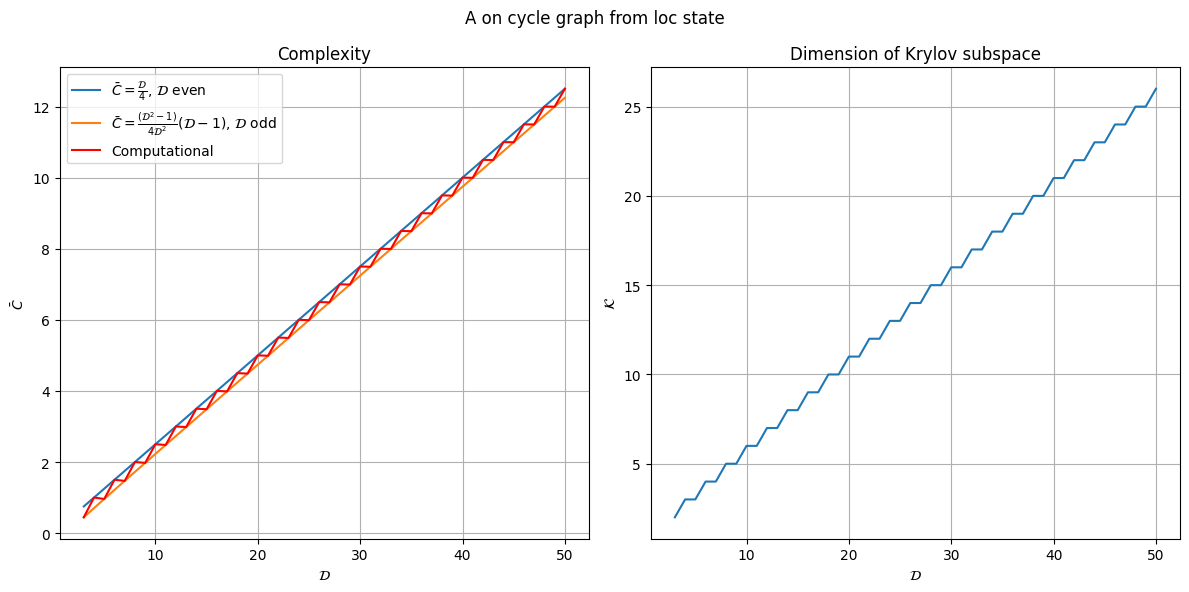

In [91]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("A on cycle graph from loc state")

axx[0].grid(True)
axx[0].plot(an_x,an_y_cycle_even, label=r"$\bar{C}=\frac{\mathcal{D}}{4}$, $\mathcal{D}$ even")
axx[0].plot(an_x,an_y_cycle_odd, label=r"$\bar{C}=\frac{(\mathcal{D}^2-1)}{4\mathcal{D}^2}(\mathcal{D}-1)$, $\mathcal{D}$ odd")
axx[0].plot(an_x, compl_cycle, label="Computational", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x,krylov_size)
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

and non-real graphs ($\varphi \neq 0$). $\varphi =\frac{\pi}{100}$ is chosen such that the product $d\times\varphi$ is not an integer for any $d$ under scrutiny, in order to avoid having graphs that are quasi-gauge equivalent to the real ones.

In [92]:
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

phase = np.pi/100
w = np.array([0.,np.exp(phase*1.j)], dtype=complex)

an_x, compl_circ_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial)

In [93]:
an_y_circ_cycle = (an_x-1.)/2.

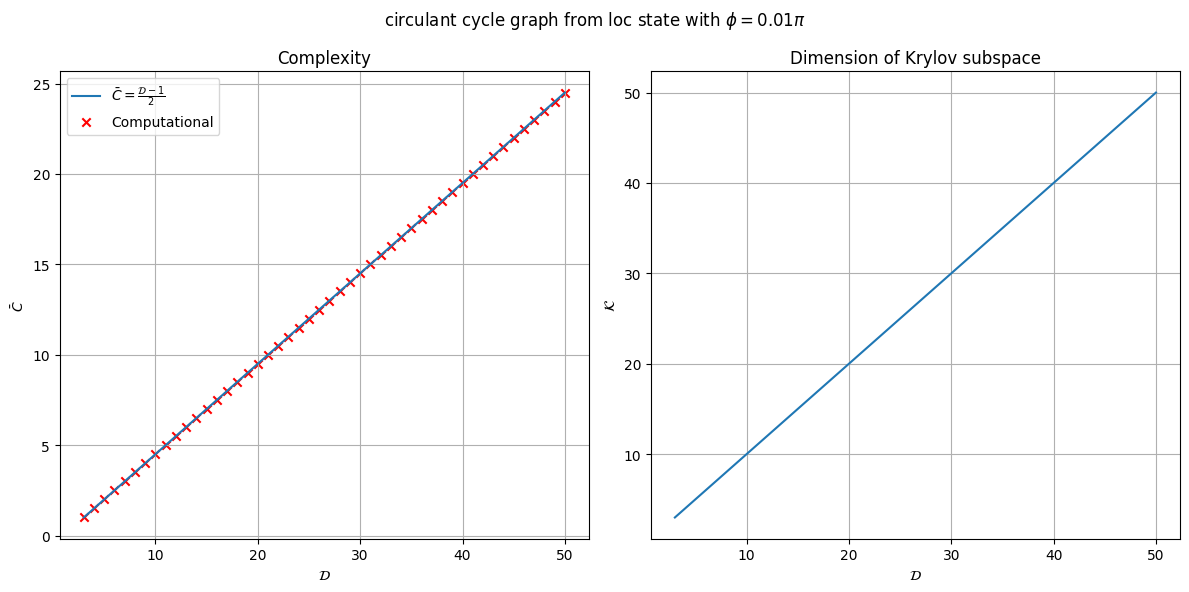

In [94]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle(r"circulant cycle graph from loc state with"+f" $\phi=${phase/np.pi}$\pi$")

axx[0].grid(True)
#axx.plot(an_x,an_y_cycle_even, label="Analytical even dim")
axx[0].plot(an_x,an_y_circ_cycle, label=r"$\bar{C}=\frac{\mathcal{D}-1}{2}$")
axx[0].scatter(an_x, compl_circ_cycle, label="Computational", marker="x", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

### Higher connectivity graphs

$\varphi = 0$

In [95]:
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.,1.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial)

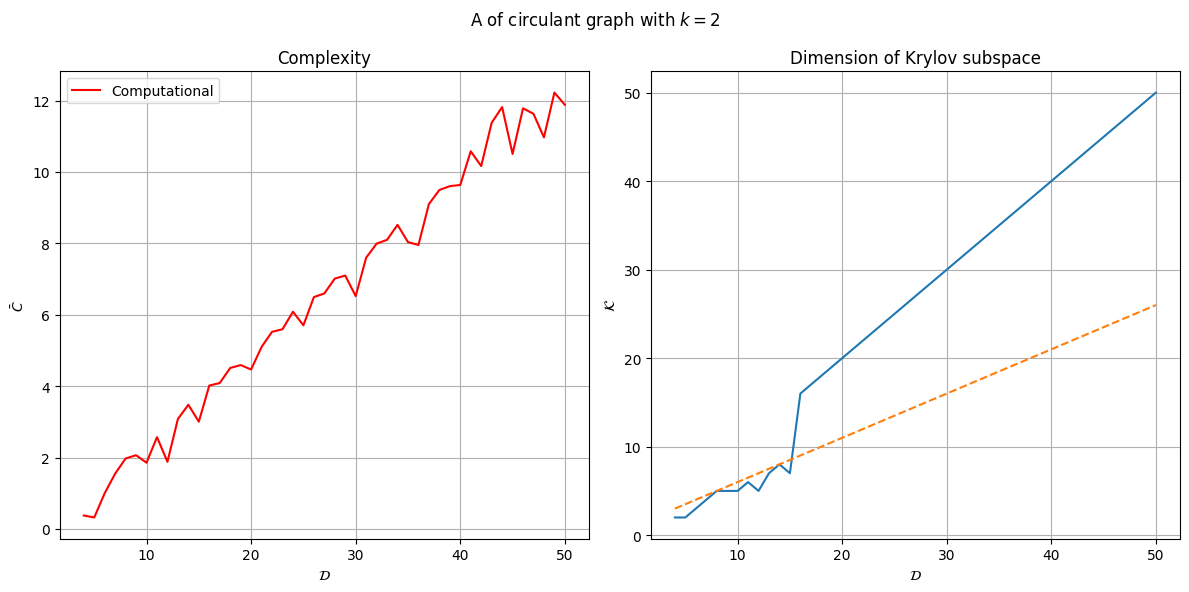

In [96]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("A of circulant graph with $k=2$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, label="Computational", color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].plot(an_x, an_x/2+1, linestyle='--')
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

In [97]:
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.,1.,1.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial)

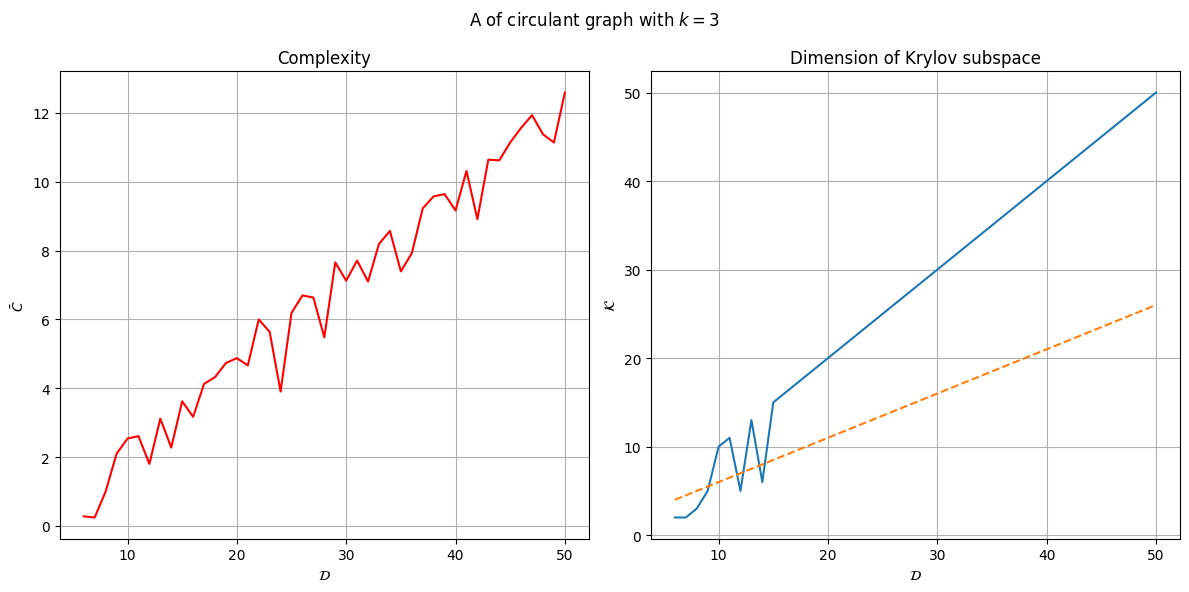

In [98]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("A of circulant graph with $k=3$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
#axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].plot(an_x, an_x/2+1, linestyle='--')
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

In [99]:
initial = np.zeros(2, dtype=complex)
initial[0] = 1.0+0.j

w = np.array([0.,1.,1.,1.,1.])

an_x, compl_cycle, krylov_size = circulant_routine(d_max=50, weights=w, initial=initial)

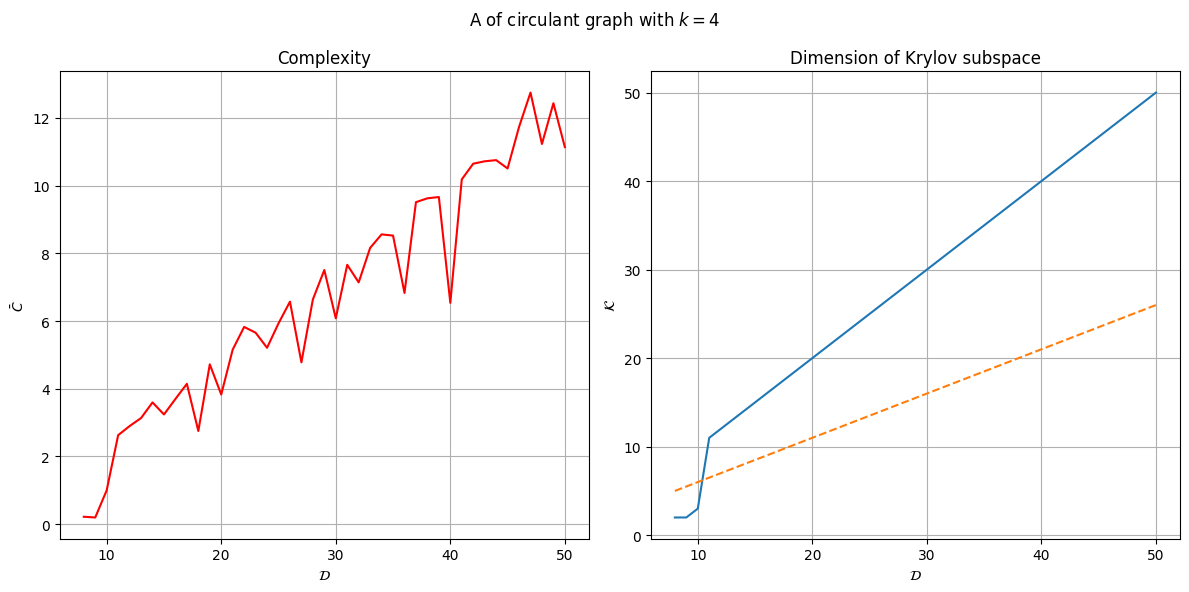

In [100]:
fig, axx = plt.subplots(1,2, figsize=(12,6), tight_layout=True)

fig.suptitle("A of circulant graph with $k=4$")
axx[0].grid(True)
axx[0].plot(an_x, compl_cycle, color="r")
axx[0].set_title(r"Complexity")
axx[0].set_ylabel(r"$\bar{C}$")
axx[0].set_xlabel(r"$\mathcal{D}$")
#axx[0].legend()

axx[1].grid(True)
axx[1].plot(an_x, krylov_size)
axx[1].plot(an_x, an_x/2+1, linestyle='--')
axx[1].set_title("Dimension of Krylov subspace")
axx[1].set_ylabel(r"$\mathcal{K}$")
axx[1].set_xlabel(r"$\mathcal{D}$")
plt.show()

The Lanczos algorithm is likely numerically unstable: the dimension of the Krylov subspace should never exceed a value around $\frac{d}{2}$, because any non-chiral circulant Hamiltonian always exhibits a two-fold degeneracy $E_m = E_{d-m}$, for those $m$ such that $m \neq d-m$ mod $d$. This degeneracy is a consequence of the time-reversal symmetry, so it's surely true.

$\mathcal{K}=d$ should be impossible, yet the algorithm gives consistently this result for any $d>d_{crit}$, where $d_{crit}$ decreases as the connectivity $k$ increases. 

My conjecture is that the numerical precision errors accumulate, such that at some point, when one should get $b_n=0$, or at least $b_n< \epsilon$, with $\epsilon \sim 10^{-6}$, the algorithm wrongfully computes $b_n > \epsilon$, and it goes on.

However, while $\mathcal{K}$ suddenly increases, $\bar{\mathcal{C}}$ doesn't: my conjecture is that, even though the Krylov coefficients are "imprecise", to say the least, the overlaps between the initial state and the "fake" Krylov states are so small that the overall error on $\bar{\mathcal{C}}$ is not so significant. 

I probably should look for a smarter implementation of the Lanczos algorithm and change it entirely.

UPDATE: I have imported the library krypy to implement the Krylov subspace computation for me, but the code runs in the same inconsistent behaviour. My online research of better implementations has proved unfruitful. 

We just have to hope that the complexity is not so sensitive to this unphysical states.